<a href="https://colab.research.google.com/github/faizahm-gif/iiit-h_AIML-TrainingProgram/blob/main/Predicting_wine_quality(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Analyzing` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.
Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [1]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.tail(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
6487,red,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,5
6488,red,6.3,0.550,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6
6489,red,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6
6490,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6491,red,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
6496,red,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [2]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [3]:
wine.dropna(inplace=True)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [5]:
y=wine['type']
X=wine.iloc[:,2:]

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
knn = KNeighborsClassifier()

In [8]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [9]:
y_pred= knn.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9319412219644239

In [11]:
import time
start = time.time()
y_pred= knn.predict(X_test)
print(time.time()-start)

0.0499267578125


<h1> With PCA

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler= StandardScaler()

In [14]:
X_train_trf = scaler.fit_transform(X_train)
X_test_trf=scaler.fit_transform(X_test)

In [15]:
X_train

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
459,0.43,0.35,9.1,0.059,83.0,249.0,0.99710,3.37,0.50,8.500000,5
1460,0.17,0.74,3.6,0.050,29.0,128.0,0.99280,3.28,0.40,12.400000,6
4403,0.22,0.46,6.2,0.066,41.0,187.0,0.99362,3.19,0.42,9.733333,5
3828,0.40,0.24,5.1,0.036,43.0,131.0,0.99186,3.24,0.44,11.300000,6
4317,0.34,0.26,1.9,0.038,58.0,138.0,0.98930,3.00,0.47,12.200000,7
...,...,...,...,...,...,...,...,...,...,...,...
3798,0.21,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.900000,5
5219,0.61,0.26,3.4,0.090,25.0,87.0,0.99975,3.24,0.62,9.700000,5
5254,0.41,0.52,3.0,0.080,29.0,55.0,1.00010,3.26,0.88,11.000000,5
5418,0.25,0.49,2.7,0.088,15.0,33.0,0.99820,3.42,0.90,10.000000,6


In [16]:
X_train_trf

array([[ 0.56588915,  0.22079121,  0.75048207, ..., -0.20357893,
        -1.66472797, -0.93938515],
       [-1.02945526,  2.92098728, -0.3929423 , ..., -0.87653487,
         1.63149383,  0.21147296],
       [-0.72265826,  0.98238498,  0.14758559, ..., -0.74194369,
        -0.62233304, -0.93938515],
       ...,
       [ 0.44317035,  1.39779975, -0.5176795 , ...,  2.35365364,
         0.44823472, -0.93938515],
       [-0.53858006,  1.19009236, -0.58004811, ...,  2.48824482,
        -0.39695035,  0.21147296],
       [ 0.13637334,  0.84391338, -0.74636438, ..., -0.33817012,
        -0.48146886,  0.21147296]])

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_trf)
X_test_pca = pca.transform(X_test_trf)

In [18]:
X_train_pca.shape

(5170, 2)

In [19]:
knn = KNeighborsClassifier()

In [20]:
knn.fit(X_train_pca,y_train)

KNeighborsClassifier()

In [21]:
y_pred_pca= knn.predict(X_test_pca)

In [22]:
accuracy_score(y_test,y_pred_pca)

0.9775715390564579

In [23]:
import time
start = time.time()
y_pred_pca= knn.predict(X_test_pca)
print(time.time()-start)

0.01886773109436035


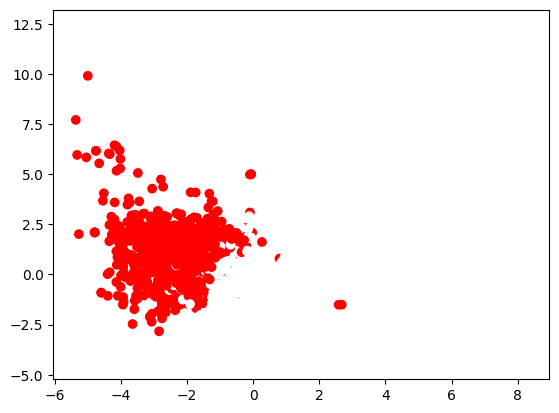

In [24]:
import matplotlib.pyplot as plt
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train)
plt.show()